# Basic EDA of Shifts dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet('../data/shifts.parquet')
df.head()

,Date,Home_Team,Away_Team,Team,Player_Id,shift_number,period,start_clock,end_clock,shift_length
0,2025-10-11,Team D,Team A,Team A,29,1,1,20:00,19:05,00:55
1,2025-10-11,Team D,Team A,Team A,48,1,1,20:00,19:27,00:33
2,2025-10-11,Team D,Team A,Team A,Go,1,1,20:00,00:00,20:00
3,2025-10-11,Team D,Team A,Team A,63,1,1,20:00,19:04,00:56
4,2025-10-11,Team D,Team A,Team A,5,1,1,20:00,19:27,00:33


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df['Date_Game'] = df['Date'].astype(str) + ' ' + df['Home_Team'] + ' @ ' + df['Away_Team']

games = df['Date_Game'].unique()
print(f"Available games: {games}")

selected_game = games[3]
game_data = df[df['Date_Game'] == selected_game].copy()

print(f"\nSelected game: {selected_game}")
print(f"Unique players: {game_data['Player_Id'].nunique()}")

Available games: <ArrowStringArray>
['2025-10-11 Team D @ Team A', '2025-10-17 Team L @ Team F',
 '2025-10-24 Team A @ Team B', '2025-10-24 Team D @ Team E',
 '2025-10-28 Team A @ Team C', '2025-10-29 Team L @ Team G',
 '2025-11-02 Team A @ Team D', '2025-11-16 Team K @ Team H',
 '2025-11-19 Team K @ Team I', '2025-11-28 Team K @ Team J']
Length: 10, dtype: str

Selected game: 2025-10-24 Team D @ Team E
Unique players: 33


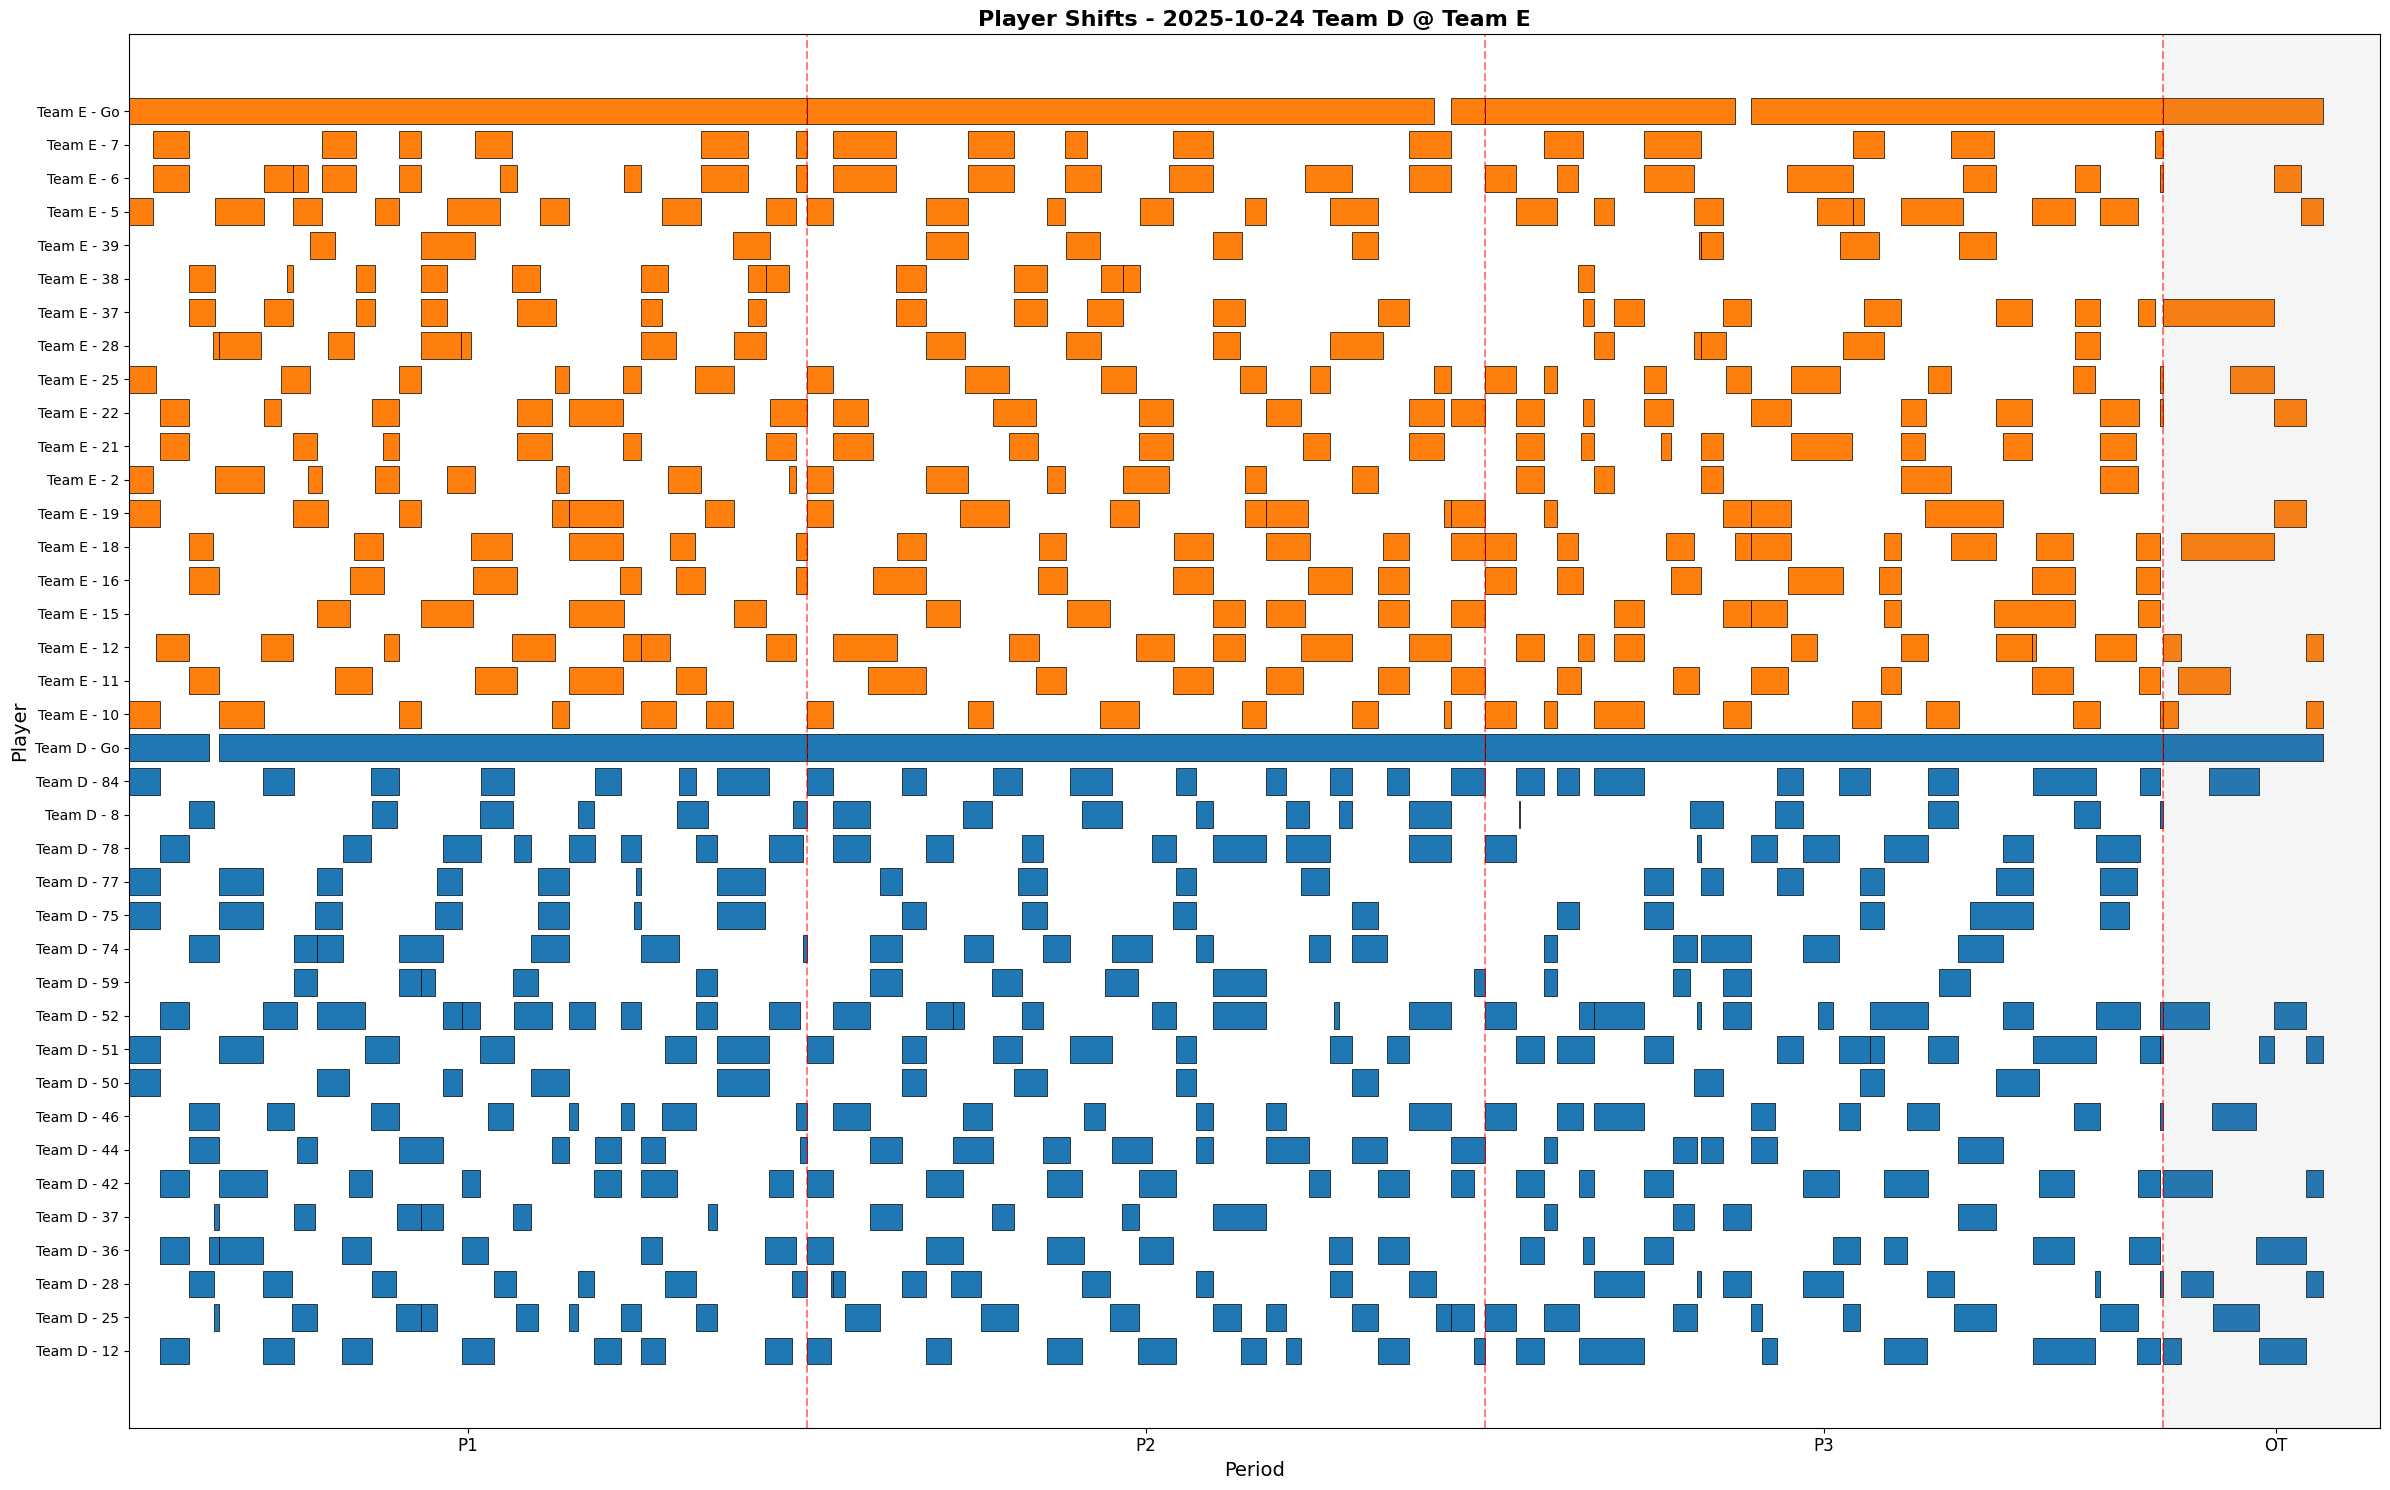

In [10]:
def clock_to_seconds(clock_str, period):
    parts = str(clock_str).split(':')
    minutes = int(parts[0])
    seconds = int(parts[1])
    clock_seconds = minutes * 60 + seconds
    
    if period == 4:
        return 3600 + (300 - clock_seconds)
    else:
        period_int = int(period)
        return (period_int - 1) * 1200 + (1200 - clock_seconds)

game_data['start_seconds'] = game_data.apply(lambda row: clock_to_seconds(row['start_clock'], row['period']), axis=1)
game_data['end_seconds'] = game_data.apply(lambda row: clock_to_seconds(row['end_clock'], row['period']), axis=1)

game_data = game_data.sort_values('start_seconds')

plt.figure(figsize=(24, 15))

palette = {'Team D': '#1f77b4', 'Team E': '#ff7f0e'}
game_data_sorted = game_data.sort_values(['Team', 'Player_Id'])

for idx, (_, row) in enumerate(game_data_sorted.iterrows()):
    player_label = f"{row['Team']} - {row['Player_Id']}"
    start = row['start_seconds']
    duration = row['end_seconds'] - row['start_seconds']
    
    if duration < 0:
        duration = abs(duration)
    
    plt.barh(player_label, duration, left=start, height=0.8, 
             color=palette.get(row['Team'], 'gray'), edgecolor='black', linewidth=0.5)

max_seconds = game_data[['start_seconds', 'end_seconds']].max().max()

plt.axvline(x=1200, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
plt.axvline(x=2400, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
plt.axvline(x=3600, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

plt.axvspan(3600, max_seconds + 100, alpha=0.08, color='grey', label='Overtime')

ax = plt.gca()
ax.set_xticks([600, 1800, 3000, 3800])
ax.set_xticklabels(['P1', 'P2', 'P3', 'OT'], fontsize=12)

plt.xlabel('Period', fontsize=14)
plt.ylabel('Player', fontsize=14)
plt.title(f'Player Shifts - {selected_game}', fontsize=16, fontweight='bold')
plt.xlim(0, max_seconds + 100)
plt.tight_layout()
plt.show()

In [2]:
import sys, warnings
sys.path.insert(0, '..')
sys.path.insert(0, '../stamina_models')
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
from build_shift_df import build_shift_df

sdf = build_shift_df('../data', force=False)
sdf['shift_duration_min'] = sdf['shift_duration_s'] / 60.0
sdf = sdf.dropna(subset=['cumulative_ice_min_before', 'shift_duration_min'])
print(f'{len(sdf):,} shifts loaded')


Loading cached shift_df from /Users/joeharter/repos/bdc-2026/exploration/../stamina_models/shift_df.parquet
6,218 shifts loaded


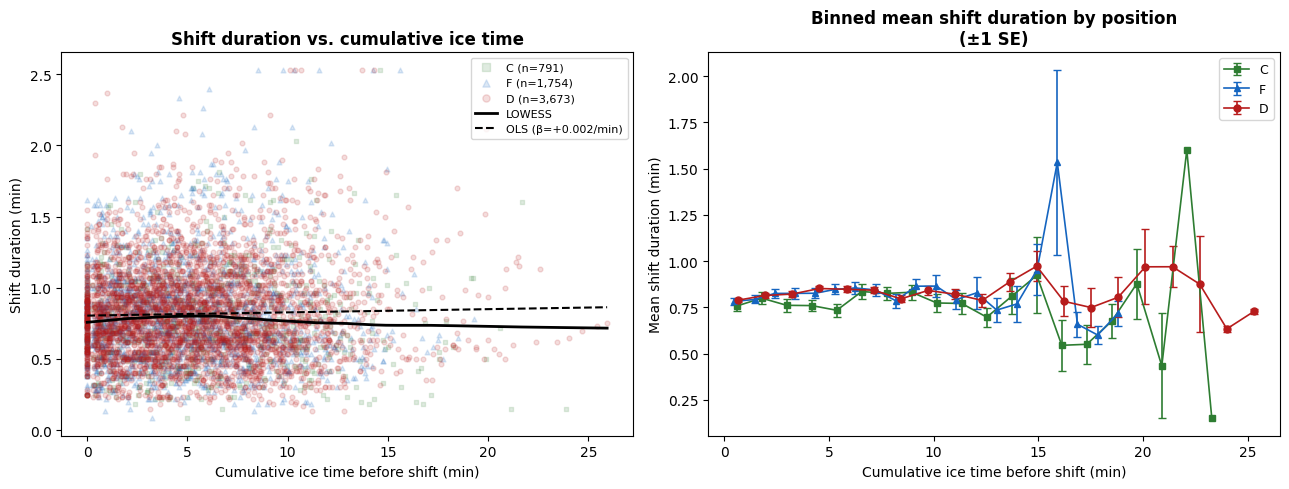

                    Results: Ordinary least squares
Model:               OLS                 Adj. R-squared:      0.001    
Dependent Variable:  shift_duration_min  AIC:                 4027.8423
Date:                2026-03-15 19:50    BIC:                 4041.3127
No. Observations:    6218                Log-Likelihood:      -2011.9  
Df Model:            1                   F-statistic:         4.552    
Df Residuals:        6216                Prob (F-statistic):  0.0329   
R-squared:           0.001               Scale:               0.11187  
-----------------------------------------------------------------------
                          Coef.  Std.Err.    t     P>|t|  [0.025 0.975]
-----------------------------------------------------------------------
Intercept                 0.8047   0.0071 112.5431 0.0000 0.7906 0.8187
cumulative_ice_min_before 0.0023   0.0011   2.1334 0.0329 0.0002 0.0044
-----------------------------------------------------------------------
Omnibus:    

In [4]:
from build_shift_df import POS_COLORS

# ── OLS: shift_duration_min ~ cumulative_ice_min_before ───────────────────────
ols = smf.ols('shift_duration_min ~ cumulative_ice_min_before', data=sdf).fit()
beta = ols.params['cumulative_ice_min_before']

# ── Binned means (cleaner than raw scatter at 6k points) ─────────────────────
N_BINS = 20
sdf['cum_bin'] = pd.cut(sdf['cumulative_ice_min_before'], bins=N_BINS)

# ── LOWESS ────────────────────────────────────────────────────────────────────
lw = lowess(sdf['shift_duration_min'], sdf['cumulative_ice_min_before'], frac=0.3)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter by position + LOWESS + OLS line
ax = axes[0]
markers = {'D': 'o', 'C': 's', 'F': '^'}
for pos, col in POS_COLORS.items():
    sub = sdf[sdf['position'] == pos]
    ax.scatter(sub['cumulative_ice_min_before'], sub['shift_duration_min'],
               color=col, marker=markers[pos], alpha=0.15, s=12,
               label=f'{pos} (n={len(sub):,})', rasterized=True)

ax.plot(lw[:, 0], lw[:, 1], color='black', lw=2.0, ls='-', label='LOWESS')
x_range = np.linspace(sdf['cumulative_ice_min_before'].min(),
                      sdf['cumulative_ice_min_before'].max(), 200)
ax.plot(x_range, ols.predict(pd.DataFrame({'cumulative_ice_min_before': x_range})),
        color='black', lw=1.5, ls='--', label=f'OLS (β={beta:+.3f}/min)')

ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Shift duration (min)')
ax.set_title('Shift duration vs. cumulative ice time', fontweight='bold')
ax.legend(fontsize=8, markerscale=1.5)

# Right: binned mean ± 1 SE with position breakdown
ax = axes[1]
for pos, col in POS_COLORS.items():
    sub = sdf[sdf['position'] == pos].copy()
    sub['cum_bin'] = pd.cut(sub['cumulative_ice_min_before'], bins=N_BINS)
    bs = (sub.groupby('cum_bin', observed=True)['shift_duration_min']
            .agg(mean='mean', sem=lambda x: x.std() / np.sqrt(len(x)))
            .reset_index())
    bm = bs['cum_bin'].apply(lambda i: i.mid).astype(float)
    ax.errorbar(bm, bs['mean'], yerr=bs['sem'],
                color=col, marker=markers[pos], ms=5, lw=1.2,
                capsize=3, label=pos, linestyle='-')

ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Mean shift duration (min)')
ax.set_title('Binned mean shift duration by position\n(±1 SE)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../output/shift_duration_vs_cumice.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Model summary ─────────────────────────────────────────────────────────────
print(ols.summary2())
print(f'\nInterpretation: each additional 1 min of prior ice time → '
      f'{beta*60:+.1f} sec change in shift duration')
